# Stage 2: Body Segmentation & Cloth-Agnostic Representation

**Goal:** Understand *what* is on each pixel of the person image — which pixels are shirt, pants, face, arms, background.

**Why this matters for try-on:**  
Before we can put a new shirt on someone, we need to:
1. Know exactly which pixels currently contain their shirt (so we can erase it)
2. Know which pixels are face/hair/hands (so we preserve them — they don't get covered by clothing)
3. Create a **cloth-agnostic person** — the person with the shirt erased, ready to receive a new one

This cloth-agnostic representation is the core input to VITON-HD and similar try-on models.

**Pipeline for this stage:**
```
Person Image
    |
    v
[SegFormer Human Parser] --> 18-class body part map
    |
    ├── Upper-clothes mask  --> region to erase
    ├── Face + Hair mask    --> region to preserve
    └── Arms mask           --> region to preserve
    |
    v
Cloth-Agnostic Person (shirt erased, face/arms kept)
```

## Cell 1: Install Dependencies

**SegFormer** is a transformer-based segmentation model from NVIDIA.  
We use a version fine-tuned on fashion/clothing data that knows 18 body part labels.  
It runs entirely locally via HuggingFace — no API, no internet needed at inference time.

**rembg** uses U2Net to separate person from background — fast and reliable.

In [1]:
!pip install transformers rembg onnxruntime matplotlib opencv-python-headless -q
print("Installed.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.0/45.0 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.2/18.2 MB 98.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 97.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.1/7.1 MB 112.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.9/54.9 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.6/13.6 MB 108.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.8/3.8 MB 123.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 10.9 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
cucim-cu12 26.2.0 requires scikit-image<0.26.0,>=0.19.0, but you have scikit-image 0.26.0 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is

In [8]:
# Uninstall conflicting packages and reinstall with pinned versions
!pip uninstall rembg -y -q
!pip install "numpy<2.0" -q
!pip install "scipy>=1.13" -q
!pip install "Pillow>=9.0,<12.0" -q
!pip install transformers -q
!pip install matplotlib opencv-python-headless -q

import numpy as np
import scipy
from PIL import Image
print(f"numpy:  {np.__version__}")
print(f"scipy:  {scipy.__version__}")
print(f"Pillow: {Image.__version__}")
print("All good — restart runtime now.")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 104.8 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
rasterio 1.5.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.
cucim-cu12 26.2.0 requires scikit-image<0.26.0,>=0.19.0, but you have scikit-image 0.26.0 which is incompatible.
opencv-python 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
xarray-einstats 0.10.0 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
tobler 0.14.0 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
jaxlib 0.7.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
pytensor 2.38.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
cuml-c

## Cell 2: Mount Drive & Load Stage 1 Outputs

We load the same person image we used in Stage 1.  
Everything builds on top of each other — pose keypoints from Stage 1 will also be reused here.

In [2]:
from google.colab import drive
import os, cv2
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

drive.mount('/content/drive')

BASE_DIR    = '/content/drive/MyDrive/VirtualTryOn'
INPUT_DIR   = os.path.join(BASE_DIR, 'input_images')
OUTPUT_DIR  = os.path.join(BASE_DIR, 'output_images')
TEST_IMAGE_PATH = os.path.join(INPUT_DIR, 'test_person.jpg')

image_bgr = cv2.imread(TEST_IMAGE_PATH)
image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
h, w, _   = image_rgb.shape
pil_image = Image.fromarray(image_rgb)

print(f"Loaded image: {TEST_IMAGE_PATH}")
print(f"Shape: {image_rgb.shape}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Loaded image: /content/drive/MyDrive/VirtualTryOn/input_images/test_person.jpg
Shape: (1280, 561, 3)


## Cell 3: Background Removal

**rembg** runs U2Net (a salient object detection network) to separate the person from the background.  
Output: an RGBA image where the background alpha = 0 (transparent).  

We use this to create a **binary person mask** — 1 where person pixels are, 0 elsewhere.  
This mask is used in Stage 4 to composite the final try-on result back onto the original background.

In [4]:
# Background removal skipped — we'll derive the person mask from
# SegFormer's output in Cell 4 (anything that isn't label 0 = person)
print("Skipping rembg — person mask will be derived from SegFormer segmentation.")
print("Proceeding to Cell 4...")

Skipping rembg — person mask will be derived from SegFormer segmentation.
Proceeding to Cell 4...


## Cell 4: Human Body Part Parsing (SegFormer)

We now go deeper than just person vs background — we label every pixel with a specific body part.

**Model:** `mattmdjaga/segformer_b2_clothes`  
Fine-tuned on fashion data, gives us 18 labels:

| Label | ID | Label | ID |
|---|---|---|---|
| Background | 0 | Face | 11 |
| Hat | 1 | Left Leg | 12 |
| Hair | 2 | Right Leg | 13 |
| Sunglasses | 3 | Left Arm | 14 |
| **Upper Clothes** | **4** | **Right Arm** | **15** |
| Skirt | 5 | Bag | 16 |
| Pants | 6 | Scarf | 17 |
| Dress | 7 | | |

**Key for try-on:** Upper Clothes (4) = erase this. Face (11) + Hair (2) + Arms (14,15) = preserve these.

Using device: cuda
Loading SegFormer human parser...


Loading weights:   0%|          | 0/380 [00:00<?, ?it/s]

Model loaded.
Segmentation map shape: (1280, 561)
Labels found in image: [0, 2, 3, 4, 6, 9, 10, 11, 14, 15]


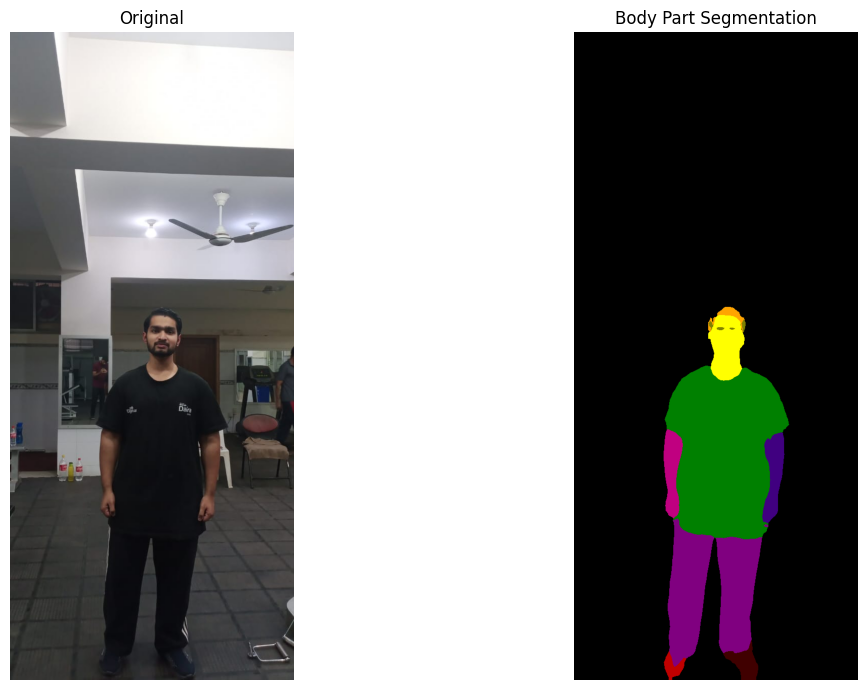


Key region coverage:
  Upper clothes       : 8.4%
  Face                : 1.0%
  Hair                : 0.1%
  Left arm            : 0.7%
  Right arm           : 0.6%
  Pants               : 4.5%

Person mask saved. Person covers 15.9% of image.


In [3]:
import torch
from transformers import SegformerImageProcessor, SegformerForSemanticSegmentation
import torch.nn.functional as F

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}")

# Load model (downloads once, ~120MB)
print("Loading SegFormer human parser...")
processor = SegformerImageProcessor.from_pretrained("mattmdjaga/segformer_b2_clothes")
model     = SegformerForSemanticSegmentation.from_pretrained("mattmdjaga/segformer_b2_clothes").to(device)
model.eval()
print("Model loaded.")

# Run inference
inputs  = processor(images=pil_image, return_tensors="pt").to(device)
with torch.no_grad():
    outputs = model(**inputs)

# Upsample logits back to original image size
logits_upsampled = F.interpolate(
    outputs.logits,
    size=(h, w),
    mode='bilinear',
    align_corners=False
)
seg_map = logits_upsampled.argmax(dim=1).squeeze().cpu().numpy()  # shape: (h, w)

# Save raw segmentation map
np.save(os.path.join(OUTPUT_DIR, 'seg_map.npy'), seg_map)
print(f"Segmentation map shape: {seg_map.shape}")
print(f"Labels found in image: {sorted(np.unique(seg_map).tolist())}")

# Color-code the segmentation map for visualization
LABEL_COLORS = {
    0:  [0,   0,   0  ],  # Background
    1:  [128, 0,   0  ],  # Hat
    2:  [255, 165, 0  ],  # Hair
    3:  [128, 128, 0  ],  # Sunglasses
    4:  [0,   128, 0  ],  # Upper clothes  <-- KEY
    5:  [0,   0,   128],  # Skirt
    6:  [128, 0,   128],  # Pants
    7:  [0,   128, 128],  # Dress
    8:  [128, 128, 128],  # Belt
    9:  [64,  0,   0  ],  # Left shoe
    10: [192, 0,   0  ],  # Right shoe
    11: [255, 255, 0  ],  # Face           <-- KEY
    12: [64,  128, 0  ],  # Left leg
    13: [192, 128, 0  ],  # Right leg
    14: [64,  0,   128],  # Left arm       <-- KEY
    15: [192, 0,   128],  # Right arm      <-- KEY
    16: [64,  128, 128],  # Bag
    17: [192, 128, 128],  # Scarf
}

color_seg = np.zeros((h, w, 3), dtype=np.uint8)
for label_id, color in LABEL_COLORS.items():
    color_seg[seg_map == label_id] = color

# Save colored segmentation
cv2.imwrite(
    os.path.join(OUTPUT_DIR, 'seg_colored.png'),
    cv2.cvtColor(color_seg, cv2.COLOR_RGB2BGR)
)

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 7))
axes[0].imshow(image_rgb)
axes[0].set_title('Original')
axes[0].axis('off')
axes[1].imshow(color_seg)
axes[1].set_title('Body Part Segmentation')
axes[1].axis('off')
plt.tight_layout()
plt.show()

# Print coverage stats for key regions
LABEL_NAMES = {4: 'Upper clothes', 11: 'Face', 2: 'Hair', 14: 'Left arm', 15: 'Right arm', 6: 'Pants'}
print("\nKey region coverage:")
for lid, lname in LABEL_NAMES.items():
    pct = (seg_map == lid).sum() / (h * w) * 100
    print(f"  {lname:<20}: {pct:.1f}%")


# Derive person mask from segmentation (all non-background labels = person)
person_mask = (seg_map != 0).astype(np.uint8) * 255
mask_path = os.path.join(OUTPUT_DIR, 'person_mask.png')
cv2.imwrite(mask_path, person_mask)
person_pixel_pct = (person_mask > 0).sum() / (h * w) * 100
print(f"\nPerson mask saved. Person covers {person_pixel_pct:.1f}% of image.")

## Cell 5: Create the Cloth-Agnostic Representation

This is the key output of Stage 2. The **cloth-agnostic person** is what VITON-HD calls the  
"person without clothes" — specifically:
- **Erased:** Upper clothes region (label 4) → filled with gray
- **Preserved:** Face (11), Hair (2), Left arm (14), Right arm (15)
- **Preserved:** Everything below the waist (pants, legs, shoes)

Why preserve arms? Because arms often overlap with the shirt. If we erase arms along with  
the shirt, the model loses positional information it needs to realistically place the new garment.

**This agnostic image + pose map from Stage 1 = the full conditioning input for the try-on model.**

In [4]:
# Labels to ERASE (replace with gray — these are covered by the new garment)
ERASE_LABELS  = [4, 7, 8, 17]  # upper-clothes, dress, belt, scarf

# Labels to PRESERVE (keep original pixels)
PRESERVE_LABELS = [2, 11, 14, 15]  # hair, face, left arm, right arm

# Build the erase mask
erase_mask = np.zeros((h, w), dtype=bool)
for lid in ERASE_LABELS:
    erase_mask |= (seg_map == lid)

# Build preserve mask (arms/face override the erase mask)
preserve_mask = np.zeros((h, w), dtype=bool)
for lid in PRESERVE_LABELS:
    preserve_mask |= (seg_map == lid)

# Final mask: erase upper clothes BUT keep preserved regions
final_erase = erase_mask & ~preserve_mask

# Apply: fill erased region with neutral gray (128)
agnostic = image_rgb.copy()
agnostic[final_erase] = [128, 128, 128]

# Save outputs
agnostic_path = os.path.join(OUTPUT_DIR, 'agnostic_person.png')
erase_mask_path = os.path.join(OUTPUT_DIR, 'erase_mask.png')

cv2.imwrite(agnostic_path,    cv2.cvtColor(agnostic, cv2.COLOR_RGB2BGR))
cv2.imwrite(erase_mask_path,  (final_erase * 255).astype(np.uint8))

print(f"Cloth-agnostic person saved to: {agnostic_path}")
print(f"Erase mask saved to: {erase_mask_path}")
print(f"Pixels erased: {final_erase.sum()} ({final_erase.sum()/(h*w)*100:.1f}% of image)")

Cloth-agnostic person saved to: /content/drive/MyDrive/VirtualTryOn/output_images/agnostic_person.png
Erase mask saved to: /content/drive/MyDrive/VirtualTryOn/output_images/erase_mask.png
Pixels erased: 60492 (8.4% of image)


## Cell 6: Final Visualization

Three-panel view of Stage 2's output:
- **Left:** Original person
- **Center:** Body part segmentation map
- **Right:** Cloth-agnostic person (shirt region erased, face/arms preserved)

Check: the gray region should roughly cover the shirt/torso area, while the face, hair, and arms should still show original pixels.

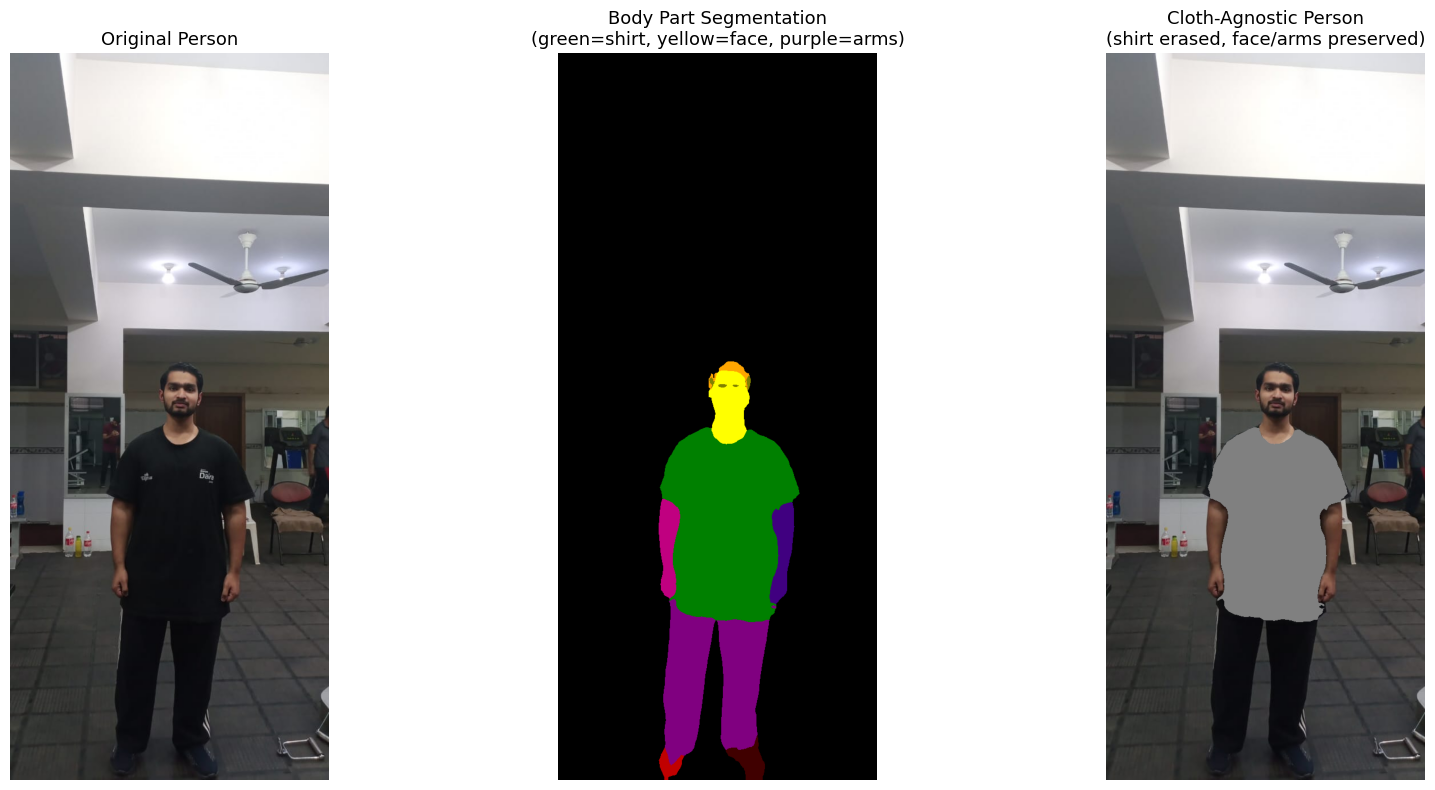

Stage 2 complete!
Outputs saved to Google Drive:
  OK person_mask.png
  OK seg_map.npy
  OK seg_colored.png
  OK agnostic_person.png
  OK erase_mask.png
  OK stage2_comparison.jpg


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18, 8))

axes[0].imshow(image_rgb)
axes[0].set_title('Original Person', fontsize=13)
axes[0].axis('off')

axes[1].imshow(color_seg)
axes[1].set_title('Body Part Segmentation\n(green=shirt, yellow=face, purple=arms)', fontsize=13)
axes[1].axis('off')

axes[2].imshow(agnostic)
axes[2].set_title('Cloth-Agnostic Person\n(shirt erased, face/arms preserved)', fontsize=13)
axes[2].axis('off')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'stage2_comparison.jpg'), dpi=150, bbox_inches='tight')
plt.show()

print("Stage 2 complete!")
print("Outputs saved to Google Drive:")
for fname in ['person_mask.png', 'seg_map.npy', 'seg_colored.png', 'agnostic_person.png', 'erase_mask.png', 'stage2_comparison.jpg']:
    path = os.path.join(OUTPUT_DIR, fname)
    exists = os.path.exists(path)
    print(f"  {'OK' if exists else 'MISSING'} {fname}")

---
## What we learned in Stage 2

- **Human parsing** gives pixel-level labels for 18 body regions — far more useful than just person vs. background
- The **cloth-agnostic representation** (person with shirt erased) is the primary input to the try-on model
- Preserving arms while erasing the shirt is a deliberate design choice — arms provide spatial anchoring

### How this fits the pipeline:
```
[Stage 1 outputs]          [Stage 2 outputs]
  pose_output.jpg    +       agnostic_person.png
  (skeleton map)             (shirt erased)
        |
        v
[Stage 3: Clothing Warping]
  Deform the flat garment image to match the body pose
        |
        v
[Stage 4: Try-On Synthesis]
  Blend warped garment onto the agnostic person
```

**Next: Stage 3** — take a flat product image of a shirt and warp it to fit the detected body shape.